# PEFT Fine-Tuning Comparison v2 — OxfordIIITPet
## LoRA vs VeRA vs DoRA vs AdaLoRA vs IA3 vs TinyLoRA on OxfordIIITPet

This is the OxfordIIITPet companion to the CIFAR-10 / CIFAR-100 / Food101 / STL-10 / Flowers102
professor-spec notebooks. Like Food101, this is a real-photo, variable-resolution dataset; like
CIFAR/Food101/STL-10 (and unlike Flowers102), it ships only a train+test split, so we perform our
own stratified 80/20 split. Those methodology points are called out explicitly below.

1. Random seed = 42 everywhere, for reproducibility.
2. Full OxfordIIITPet `trainval` split (3,680 images) split 80/20 into sub-train / validation (no subsetting).
3. 10 epochs for all experiments. LR grid = {0.001, 0.0005} compared for every method **except VeRA**, which uses a fixed LR = 0.01.
4. `target_modules = q_proj|v_proj` (attention only).
5. Model selection is done on the **validation** set; the reported number for each run is **test accuracy on the untouched OxfordIIITPet `test` split**, evaluated exactly once per run using the best-validation checkpoint.
6. Six methods: LoRA, VeRA, DoRA, AdaLoRA, IA3, TinyLoRA — plus a TinyLoRA high-LR run (0.01), carried over from the CIFAR experiments, since TinyLoRA showed a "stuck near random-guess loss" signature there that the same fix (raising LR ~20x) resolved for VeRA.
7. All test accuracies (plus val accuracy, F1, timing) are saved to JSON/Markdown for the report.

**What's substantively different about OxfordIIITPet (not just relabeling):**
- **37 classes** of cat and dog breeds, from torchvision's `OxfordIIITPet` with `target_types='category'` (the default) -- giving a single integer breed label per image, not the dataset's alternative binary cat/dog label or segmentation mask, which this notebook does not use.
- **Only two official splits**: `trainval` (3,680 images) and `test` (3,669 images) -- like CIFAR/Food101/STL-10 (and unlike Flowers102's three-way split), so we perform our own stratified 80/20 split of `trainval` into sub-train (~2,944 images) and validation (~736 images).
- **Real photos of varying resolution**, like Food101 -- resizing happens inside the transform pipeline (before batching), `resize_images()` is a no-op, and ImageNet normalization statistics are used, for the same reasons as Food101.
- **Moderate dataset size**: bigger than Flowers102's 1,020-image training set, smaller than Food101's 75,750 -- a middle ground, and one of the more balanced-per-class datasets in this series (~99 images/class in `trainval`, versus Food101's fixed 750/class or Flowers102's fixed 10/class).

**Runtime note:** 12 total training runs, each 10 epochs over ~2,944 training images. Images are decoded from JPEG on the fly (like Food101), so budget more wall-clock time than the CIFAR/STL-10 notebooks, though this dataset is far smaller than Food101's ~101,000 images, so it should run considerably faster than the Food101 notebook. Results are saved incrementally after each run so a crash or timeout doesn't lose completed runs.


## 1. Setup and Installation

In [1]:
# Mount Google Drive (optional, for saving results)
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
#import subprocess
#import sys
#
#packages = [
#    'peft>=0.19.1',   # TinyLoraConfig, AdaLoraConfig, IA3Config, VeraConfig all live here
#    'transformers',
#    'torch',
#    'torchvision',
#    'accelerate',
#    'datasets',
#    'numpy',
#    'matplotlib',
#    'tqdm',
#    'scikit-learn',
#    'torchao>=0.16.0',   # FIX: Colab ships torchao 0.10.0. peft's LoraConfig dispatcher (used by
#                          # both LoRA and DoRA, since DoRA = LoraConfig(use_dora=True)) checks
#                          # torchao's version and raises ImportError if it's older than 0.16.0.
#                          # AdaLoRA/IA3/TinyLoRA/VeRA use separate tuner classes and don't hit this.
#]
#
#print("Installing required packages...")
#subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade'] + packages)
#print("Installation complete!")


In [3]:
# Verify GPU availability
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: NVIDIA L4
GPU memory: 23.66 GB


## 2. Imports, Global Config, and Reproducibility

In [4]:
import os
import json
import random
import copy
import shutil
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import Resize
from transformers import AutoModel
from peft import (
    get_peft_model,
    LoraConfig,
    VeraConfig,
    AdaLoraConfig,
    IA3Config,
    TinyLoraConfig,
    PeftModel,
)
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# ---- Global config ----
SEED = 42
EPOCHS = 10
LR_GRID = [0.001, 0.0005]          # compared for every method except VeRA
VERA_LEARNING_RATE = 0.01          # VeRA needs a much larger LR (see prior fix); not part of the grid comparison
BATCH_SIZE = 64
TARGET_MODULES = r".*(q_proj|v_proj)$"
MODEL_NAME = 'google/vit-base-patch16-224-in21k'
NUM_CLASSES = 37                   # OxfordIIITPet has 37 cat/dog breed categories
VAL_FRACTION = 0.20                # 80/20 split of the TRAINING set only

def set_seed(seed=SEED):
    """Reset every RNG so each run starts from an identical, reproducible state."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"Seed: {SEED} | Epochs: {EPOCHS} | LR grid: {LR_GRID} | VeRA LR: {VERA_LEARNING_RATE}")


Using device: cuda
Seed: 42 | Epochs: 10 | LR grid: [0.001, 0.0005] | VeRA LR: 0.01


## 3. Data Preparation

Per the professor's instructions, adapted for OxfordIIITPet:
- **Do not subsample.** Load the full `trainval` split (3,680 images) and the full `test` split (3,669 images).
- Split the **`trainval` split only** into sub-train (80%) and validation (20%), stratified by class so each split has balanced classes, with `random_state=42` for reproducibility.
- The **`test` split is never split or touched** until final evaluation of the best checkpoint.
- Validation images use the *eval-time* transform (resize + center-crop only, no random crop/flip).

**Difference from CIFAR:** OxfordIIITPet uses `split='trainval'` / `split='test'` (like Food101's `split='train'`/`'test'`), not CIFAR's `train=True/False`. We explicitly pass `target_types='category'` to get the 37-breed integer label (the dataset can alternatively return a binary cat/dog label or a segmentation mask, neither of which we want here). Class labels for stratification come from the dataset's internal `_labels` list (same attribute name convention as Food101 and Flowers102), populated at construction time from a text annotation file -- no image I/O required.


In [5]:
# Define data transformations
# OxfordIIITPet images are real photos of varying resolution, like Food101 -- so we use a
# standard ImageNet-style resize-then-crop pipeline and ImageNet normalization statistics
# (appropriate since the ViT backbone was pretrained on ImageNet-21k and shares that domain).
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_eval = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Loading full OxfordIIITPet dataset (no subsetting)...")

# OxfordIIITPet uses split='trainval'/'test', not train=True/False like CIFAR.
# target_types='category' (the default) gives the 37-breed integer label.
# Images are resized INSIDE these transforms, before batching -- required, since OxfordIIITPet
# photos have varying resolutions and can't be collated into a batch tensor otherwise.
trainval_dataset_aug = datasets.OxfordIIITPet(root='./data', split='trainval', target_types='category', download=True, transform=transform_train)
trainval_dataset_noaug = datasets.OxfordIIITPet(root='./data', split='trainval', target_types='category', download=True, transform=transform_eval)
test_dataset = datasets.OxfordIIITPet(root='./data', split='test', target_types='category', download=True, transform=transform_eval)

# Stratified 80/20 split of the TRAINVAL split only, seeded for reproducibility.
# OxfordIIITPet exposes labels via the internal `_labels` list (same convention as Food101/
# Flowers102) -- fast, no image I/O.
all_indices = list(range(len(trainval_dataset_aug)))
all_labels = trainval_dataset_aug._labels
train_idx, val_idx = train_test_split(
    all_indices,
    test_size=VAL_FRACTION,
    random_state=SEED,
    shuffle=True,
    stratify=all_labels,
)

sub_train_dataset = Subset(trainval_dataset_aug, train_idx)     # 80%, augmented
val_dataset = Subset(trainval_dataset_noaug, val_idx)           # 20%, eval transform only
# test_dataset is used whole, untouched

print(f"Sub-train size : {len(sub_train_dataset)} (80% of {len(trainval_dataset_aug)} trainval images)")
print(f"Validation size: {len(val_dataset)} (20% of {len(trainval_dataset_aug)} trainval images)")
print(f"Test size      : {len(test_dataset)} (full test split, untouched)")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Example class names: {trainval_dataset_aug.classes[:5]}")


Loading full OxfordIIITPet dataset (no subsetting)...


100%|██████████| 792M/792M [01:05<00:00, 12.1MB/s]
100%|██████████| 19.2M/19.2M [00:03<00:00, 6.38MB/s]


Sub-train size : 2944 (80% of 3680 trainval images)
Validation size: 736 (20% of 3680 trainval images)
Test size      : 3669 (full test split, untouched)
Number of classes: 37
Example class names: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle']


In [6]:
# Create data loaders
g = torch.Generator()
g.manual_seed(SEED)

# num_workers raised from CIFAR's 2 -> 4: OxfordIIITPet decodes JPEGs from disk on every access,
# which is far slower than CIFAR's in-memory arrays, so more parallel workers helps keep the
# GPU fed. Lower this if you hit CPU/RAM limits on your Colab instance.
train_loader = DataLoader(
    sub_train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=4, pin_memory=True, generator=g
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=4, pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")


Train batches: 46
Val batches  : 12
Test batches : 58


## 4. Model Setup with Classification Head

In [7]:
class OxfordIIITPetClassificationModel(nn.Module):
    """Wrapper for ViT with classification head for OxfordIIITPet"""
    def __init__(self, model_name=MODEL_NAME, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.hidden_size = self.backbone.config.hidden_size
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values)
        cls_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(cls_output)
        return logits

def build_base_model():
    """Fresh, identically-initialized base model for each run (seed is reset by caller)."""
    model = OxfordIIITPetClassificationModel(MODEL_NAME)
    return model.to(device)

print("Model class defined successfully!")


Model class defined successfully!


## 5. Training and Evaluation Functions

In [8]:
def resize_images(images, target_size=224):
    """No-op for OxfordIIITPet. Like Food101 (and unlike CIFAR's fixed 32x32 images, which
    could be resized AFTER batching), OxfordIIITPet photos have varying resolutions and are
    already resized to `target_size` inside the torchvision transform pipeline -- BEFORE
    batching, since that's the only point at which resizing can happen for variable-sized
    images. Kept as a passthrough (rather than removing all call sites) so the rest of the
    pipeline is identical to the CIFAR notebooks."""
    return images

def train_epoch(model, loader, optimizer, criterion, device, epoch, total_epochs, scaler=None):
    """Train for one epoch. Uses AMP mixed precision when a GradScaler is provided."""
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{total_epochs}", leave=False)
    for images, labels in pbar:
        images = resize_images(images, target_size=224).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        if scaler is not None:
            with torch.autocast(device_type='cuda', dtype=torch.float16):
                logits = model(images)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': total_loss / max(1, total // labels.size(0)), 'acc': 100 * correct / total})

    return total_loss / len(loader), 100 * correct / total

@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Evaluating"):
    """Evaluate model on a given loader (used for both validation and test)."""
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc=desc, leave=False)
    for images, labels in pbar:
        images = resize_images(images, target_size=224).to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        total_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    f1 = f1_score(all_labels, all_preds, average='weighted')
    return total_loss / len(loader), accuracy, f1

def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total

print("Training and evaluation functions defined!")


Training and evaluation functions defined!


## 6. Generalized Experiment Runner

One function drives every method/LR combination identically:
- resets the seed,
- trains for `EPOCHS` epochs, tracking **train** and **validation** metrics each epoch,
- keeps the model weights from the epoch with the **best validation accuracy** (in memory, `copy.deepcopy`'d state dict — avoids repeated disk I/O across 11 runs),
- after training, loads those best-validation weights and evaluates **once** on the untouched test set,
- (AdaLoRA only) calls `update_and_allocate` after every optimizer step, as its dynamic rank-pruning schedule requires.

In [9]:
def run_experiment(method_name, lr, peft_model, epochs=EPOCHS, is_adalora=False, use_amp=True, seed=SEED):
    """
    Train `peft_model` (already wrapped by get_peft_model) for `epochs` epochs.
    Model selection uses validation accuracy; final reported metric is test accuracy
    from the best-validation checkpoint, computed exactly once.
    """
    set_seed(seed)  # re-seed so data order / dropout / init noise is identical across LR variants

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(peft_model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda') if (use_amp and device.type == 'cuda') else None

    total_steps = epochs * len(train_loader)
    global_step = 0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_val_acc = -1.0
    best_state = None
    start_time = datetime.now()

    for epoch in range(epochs):
        # --- train ---
        peft_model.train()
        total_loss, correct, total = 0.0, 0, 0
        pbar = tqdm(train_loader, desc=f"[{method_name} lr={lr}] Epoch {epoch+1}/{epochs}", leave=False)
        for images, labels in pbar:
            images = resize_images(images, target_size=224).to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            if scaler is not None:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    logits = peft_model(images)
                    loss = criterion(logits, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                logits = peft_model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()

            if is_adalora:
                # AdaLoRA's dynamic rank allocation must be updated every optimizer step
                peft_model.base_model.update_and_allocate(global_step)
            global_step += 1

            total_loss += loss.item()
            _, predicted = logits.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
            pbar.set_postfix({'loss': total_loss / max(1, total // labels.size(0)), 'acc': 100 * correct / total})

        train_loss, train_acc = total_loss / len(train_loader), 100 * correct / total

        # --- validate ---
        val_loss, val_acc, val_f1 = evaluate(peft_model, val_loader, criterion, device, desc="Validating")
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        print(f"[{method_name} lr={lr}] Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% F1: {val_f1:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(peft_model.state_dict())
            print(f"  best checkpoint updated (val acc: {best_val_acc:.2f}%)")

    training_time = (datetime.now() - start_time).total_seconds()

    # Load best-validation weights, then evaluate on the TEST set exactly once
    peft_model.load_state_dict(best_state)
    test_loss, test_acc, test_f1 = evaluate(peft_model, test_loader, criterion, device, desc="Final test eval")

    print(f"[{method_name} lr={lr}] DONE | best val acc: {best_val_acc:.2f}% | "
          f"TEST acc: {test_acc:.2f}% | test F1: {test_f1:.4f} | time: {training_time:.1f}s")

    return {
        'history': history,
        'best_val_acc': best_val_acc,
        'test_loss': test_loss,
        'test_acc': test_acc,
        'test_f1': test_f1,
        'training_time_seconds': training_time,
    }


## 7. Method Configuration Factory

Builds a fresh base model + PEFT-wrapped model for a given `(method, lr)` pair. Each call re-seeds first, so every method starts from the identical base-model initialization.

In [10]:
def build_peft_model(method_name, epochs=EPOCHS):
    """Returns (peft_model, is_adalora_flag). Always builds a fresh base model first."""
    set_seed(SEED)
    base = build_base_model()

    if method_name == 'LoRA':
        cfg = LoraConfig(r=8, lora_alpha=16, target_modules=TARGET_MODULES, lora_dropout=0.1, bias='none')
        return get_peft_model(base, cfg), False

    elif method_name == 'VeRA':
        cfg = VeraConfig(r=8, target_modules=TARGET_MODULES)
        return get_peft_model(base, cfg), False

    elif method_name == 'DoRA':
        cfg = LoraConfig(r=8, lora_alpha=16, target_modules=TARGET_MODULES, lora_dropout=0.1,
                          bias='none', use_dora=True)
        return get_peft_model(base, cfg), False

    elif method_name == 'AdaLoRA':
        total_step = epochs * len(train_loader)
        cfg = AdaLoraConfig(
            init_r=12, target_r=8,                       # start at rank 12, prune down to 8
            target_modules=TARGET_MODULES,
            lora_alpha=16, lora_dropout=0.1, bias='none',
            tinit=int(0.1 * total_step),                  # warm-up steps before pruning starts
            tfinal=int(0.7 * total_step),                 # steps at which final rank is reached
            deltaT=10,
            total_step=total_step,
        )
        return get_peft_model(base, cfg), True

    elif method_name == 'IA3':
        cfg = IA3Config(target_modules=TARGET_MODULES, feedforward_modules=[])  # attention-only, no MLP targets
        return get_peft_model(base, cfg), False

    elif method_name == 'TinyLoRA':
        cfg = TinyLoraConfig(r=2, u=64, target_modules=TARGET_MODULES, projection_seed=SEED)
        return get_peft_model(base, cfg), False

    else:
        raise ValueError(f"Unknown method: {method_name}")


## 8. Run All Experiments

Per the spec: LoRA, DoRA, AdaLoRA, IA3, TinyLoRA are each run at **both** LR = 0.001 and LR = 0.0005 for comparison. VeRA is run once at its own LR = 0.01. Results are saved to disk after every single run, so a crash partway through the sweep doesn't lose completed work — just re-run this cell and it will pick up where the results file left off.

In [12]:
RESULTS_PATH = Path('/content/drive/MyDrive/PEFT_Results/all_results_oxfordpet.json') if os.path.exists('/content/drive/MyDrive') else Path('./all_results_oxfordpet.json')
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)

# Load any previously-completed runs (resumability across sessions)
if RESULTS_PATH.exists():
    with open(RESULTS_PATH) as f:
        all_results = json.load(f)
    print(f"Resuming: {len(all_results)} run(s) already completed: {list(all_results.keys())}")
else:
    all_results = {}

# Build the full list of (method, lr) runs per the professor's spec
run_plan = []
for method in ['LoRA', 'DoRA', 'AdaLoRA', 'IA3', 'TinyLoRA']:
    for lr in LR_GRID:
        run_plan.append((method, lr))
run_plan.append(('VeRA', VERA_LEARNING_RATE))  # VeRA: single fixed LR, not part of the grid comparison

# CARRIED OVER FROM CIFAR EXPERIMENTS: TinyLoRA showed a "stuck near random-guess loss"
# signature there -- the same symptom VeRA had before its LR fix. TinyLoRA only learns a
# small vector projected through fixed random tensors (like VeRA), so the same fix is tested
# pre-emptively here too, rather than waiting to rediscover the same issue on OxfordIIITPet.
TINYLORA_HIGH_LR = 0.01
run_plan.append(('TinyLoRA', TINYLORA_HIGH_LR))

print(f"Total runs planned: {len(run_plan)}")
for m, lr in run_plan:
    print(f"  {m:10s} lr={lr}")


Total runs planned: 12
  LoRA       lr=0.001
  LoRA       lr=0.0005
  DoRA       lr=0.001
  DoRA       lr=0.0005
  AdaLoRA    lr=0.001
  AdaLoRA    lr=0.0005
  IA3        lr=0.001
  IA3        lr=0.0005
  TinyLoRA   lr=0.001
  TinyLoRA   lr=0.0005
  VeRA       lr=0.01
  TinyLoRA   lr=0.01


In [14]:
!pip install -U torchao

In [15]:
for method_name, lr in run_plan:
    run_key = f"{method_name}_lr{lr}"
    if run_key in all_results and all_results[run_key].get('status') == 'success':
        print(f"Skipping {run_key} (already completed successfully)")
        continue

    print("\n" + "=" * 70)
    print(f"RUN: {run_key}")
    print("=" * 70)

    try:
        peft_model, is_adalora = build_peft_model(method_name, epochs=EPOCHS)
        trainable, total = count_parameters(peft_model)
        print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")

        result = run_experiment(method_name, lr, peft_model, epochs=EPOCHS, is_adalora=is_adalora)
        result['method'] = method_name
        result['lr'] = lr
        result['trainable_params'] = trainable
        result['total_params'] = total
        result['status'] = 'success'

        del peft_model
        torch.cuda.empty_cache()

    except Exception as e:
        import traceback
        print(f"RUN FAILED: {run_key}\n{traceback.format_exc()}")
        result = {'method': method_name, 'lr': lr, 'status': 'failed', 'error': str(e)}

    all_results[run_key] = result
    with open(RESULTS_PATH, 'w') as f:
        json.dump(all_results, f, indent=2)
    print(f"Saved progress to {RESULTS_PATH} ({len(all_results)}/{len(run_plan)} runs done)")

print("\nAll runs complete (or already were).")



RUN: LoRA_lr0.001


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Trainable params: 294,912 / 86,712,613 (0.340%)


[LoRA lr=0.001] Epoch 1/10 | Train Loss: 3.4450 Acc: 17.12% | Val Loss: 3.1206 Acc: 43.75% F1: 0.3992
  best checkpoint updated (val acc: 43.75%)


[LoRA lr=0.001] Epoch 2/10 | Train Loss: 2.8758 Acc: 65.35% | Val Loss: 2.6618 Acc: 77.58% F1: 0.7609
  best checkpoint updated (val acc: 77.58%)


...

[TinyLoRA lr=0.01] Epoch 7/10 | Train Loss: 3.6139 Acc: 2.65% | Val Loss: 3.6184 Acc: 2.99% F1: 0.0099


[TinyLoRA lr=0.01] Epoch 8/10 | Train Loss: 3.6132 Acc: 2.92% | Val Loss: 3.6173 Acc: 3.53% F1: 0.0098
  best checkpoint updated (val acc: 3.53%)


[TinyLoRA lr=0.01] Epoch 9/10 | Train Loss: 3.6139 Acc: 2.28% | Val Loss: 3.6165 Acc: 2.99% F1: 0.0086


[TinyLoRA lr=0.01] Epoch 10/10 | Train Loss: 3.6141 Acc: 2.24% | Val Loss: 3.6169 Acc: 2.72% F1: 0.0081


[TinyLoRA lr=0.01] DONE | best val acc: 3.53% | TEST acc: 2.43% | test F1: 0.0102 | time: 171.5s
Saved progress to /content/drive/MyDrive/PEFT_Results/all_results_oxfordpet.json (12/12 runs done)

All runs complete (or already were).


## 9. Results Table — LR Comparison and Best-Per-Method Summary

In [16]:
# Full LR comparison table (professor explicitly asked to compare 0.001 vs 0.0005 vs your original choice)
print(f"{'Method':<10} {'LR':<10} {'Val Acc':<10} {'Test Acc':<10} {'Test F1':<10} {'Time (s)':<10} {'Status'}")
print("-" * 75)
for run_key, r in all_results.items():
    if r.get('status') != 'success':
        print(f"{r.get('method',''):<10} {r.get('lr',''):<10} {'--':<10} {'--':<10} {'--':<10} {'--':<10} FAILED")
        continue
    print(f"{r['method']:<10} {r['lr']:<10} {r['best_val_acc']:<10.2f} {r['test_acc']:<10.2f} "
          f"{r['test_f1']:<10.4f} {r['training_time_seconds']:<10.1f} success")

# Best LR per method, selected by TEST accuracy (per professor's instruction: comparison is
# made on test accuracy, not train/val accuracy)
print("\n" + "=" * 75)
print("BEST LR PER METHOD (selected by test accuracy)")
print("=" * 75)
best_per_method = {}
for run_key, r in all_results.items():
    if r.get('status') != 'success':
        continue
    m = r['method']
    if m not in best_per_method or r['test_acc'] > best_per_method[m]['test_acc']:
        best_per_method[m] = r

print(f"{'Method':<10} {'Best LR':<10} {'Val Acc':<10} {'Test Acc':<10} {'Test F1':<10}")
print("-" * 55)
for m, r in sorted(best_per_method.items(), key=lambda x: -x[1]['test_acc']):
    print(f"{m:<10} {r['lr']:<10} {r['best_val_acc']:<10.2f} {r['test_acc']:<10.2f} {r['test_f1']:<10.4f}")


Method     LR         Val Acc    Test Acc   Test F1    Time (s)   Status
---------------------------------------------------------------------------
LoRA       0.001      89.27      89.18      0.8889     176.1      success
LoRA       0.0005     85.87      86.26      0.8590     175.9      success
DoRA       0.001      90.08      89.42      0.8924     240.4      success
DoRA       0.0005     85.46      84.96      0.8446     240.2      success
AdaLoRA    0.001      81.79      82.07      0.8055     190.9      success
AdaLoRA    0.0005     70.65      70.54      0.6846     191.2      success
IA3        0.001      6.39       6.46       0.0461     168.9      success
IA3        0.0005     2.99       3.54       0.0271     168.8      success
TinyLoRA   0.001      4.35       4.85       0.0341     172.3      success
TinyLoRA   0.0005     3.26       2.94       0.0212     172.1      success
VeRA       0.01       72.28      68.68      0.6699     186.5      success
TinyLoRA   0.01       3.53       2.43

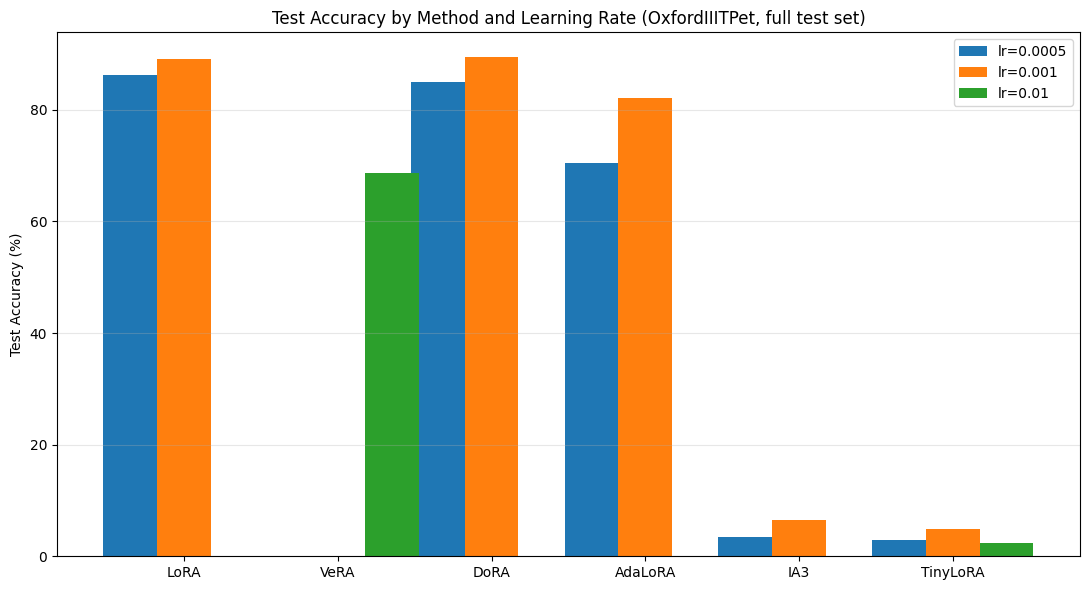

In [17]:
# Plot: test accuracy by method, grouped by LR (shows the requested LR comparison visually)
methods_order = ['LoRA', 'VeRA', 'DoRA', 'AdaLoRA', 'IA3', 'TinyLoRA']
lrs_present = sorted(set(r['lr'] for r in all_results.values() if r.get('status') == 'success'))

fig, ax = plt.subplots(figsize=(11, 6))
width = 0.35
x = np.arange(len(methods_order))

for i, lr in enumerate(lrs_present):
    vals = []
    for m in methods_order:
        key = f"{m}_lr{lr}"
        vals.append(all_results[key]['test_acc'] if key in all_results and all_results[key].get('status') == 'success' else np.nan)
    ax.bar(x + i * width - width * (len(lrs_present)-1) / 2, vals, width, label=f"lr={lr}")

ax.set_xticks(x)
ax.set_xticklabels(methods_order)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Test Accuracy by Method and Learning Rate (OxfordIIITPet, full test set)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('peft_comparison_oxfordpet.png', dpi=150)
plt.show()


## 10. Save Final Report

In [18]:
results_dir = Path('/content/drive/MyDrive/PEFT_Results') if os.path.exists('/content/drive/MyDrive') else Path('./PEFT_Results')
results_dir.mkdir(exist_ok=True, parents=True)

with open(results_dir / 'all_results_oxfordpet.json', 'w') as f:
    json.dump(all_results, f, indent=2)

try:
    shutil.copy('peft_comparison_oxfordpet.png', results_dir / 'peft_comparison_oxfordpet.png')
except Exception:
    pass

report_lines = [
    "# PEFT Fine-Tuning Comparison Report v2 — OxfordIIITPet",
    f"## Dataset: OxfordIIITPet (full) — sub-train {len(sub_train_dataset)} / val {len(val_dataset)} / test {len(test_dataset)}",
    f"## Model: {MODEL_NAME}",
    f"## Epochs: {EPOCHS} | Batch size: {BATCH_SIZE} | Seed: {SEED}",
    f"## Target modules: {TARGET_MODULES}",
    "",
    "### Full LR comparison (all runs)",
    "",
    "| Method | LR | Val Acc | Test Acc | Test F1 | Time (s) | Status |",
    "|---|---|---|---|---|---|---|",
]
for run_key, r in all_results.items():
    if r.get('status') == 'success':
        report_lines.append(f"| {r['method']} | {r['lr']} | {r['best_val_acc']:.2f}% | {r['test_acc']:.2f}% | "
                             f"{r['test_f1']:.4f} | {r['training_time_seconds']:.1f} | success |")
    else:
        report_lines.append(f"| {r.get('method','?')} | {r.get('lr','?')} | -- | -- | -- | -- | FAILED |")

report_lines += ["", "### Best LR per method (selected by test accuracy)", "",
                 "| Method | Best LR | Val Acc | Test Acc | Test F1 |", "|---|---|---|---|---|"]
for m, r in sorted(best_per_method.items(), key=lambda x: -x[1]['test_acc']):
    report_lines.append(f"| {m} | {r['lr']} | {r['best_val_acc']:.2f}% | {r['test_acc']:.2f}% | {r['test_f1']:.4f} |")

report = "\n".join(report_lines)
with open(results_dir / 'RESULTS_REPORT_oxfordpet.md', 'w') as f:
    f.write(report)

print(report)
print(f"\nSaved to {results_dir}")


# PEFT Fine-Tuning Comparison Report v2 — OxfordIIITPet
## Dataset: OxfordIIITPet (full) — sub-train 2944 / val 736 / test 3669
## Model: google/vit-base-patch16-224-in21k
## Epochs: 10 | Batch size: 64 | Seed: 42
## Target modules: .*(q_proj|v_proj)$

### Full LR comparison (all runs)

| Method | LR | Val Acc | Test Acc | Test F1 | Time (s) | Status |
|---|---|---|---|---|---|---|
| LoRA | 0.001 | 89.27% | 89.18% | 0.8889 | 176.1 | success |
| LoRA | 0.0005 | 85.87% | 86.26% | 0.8590 | 175.9 | success |
| DoRA | 0.001 | 90.08% | 89.42% | 0.8924 | 240.4 | success |
| DoRA | 0.0005 | 85.46% | 84.96% | 0.8446 | 240.2 | success |
| AdaLoRA | 0.001 | 81.79% | 82.07% | 0.8055 | 190.9 | success |
| AdaLoRA | 0.0005 | 70.65% | 70.54% | 0.6846 | 191.2 | success |
| IA3 | 0.001 | 6.39% | 6.46% | 0.0461 | 168.9 | success |
| IA3 | 0.0005 | 2.99% | 3.54% | 0.0271 | 168.8 | success |
| TinyLoRA | 0.001 | 4.35% | 4.85% | 0.0341 | 172.3 | success |
| TinyLoRA | 0.0005 | 3.26% | 2.94% | 0.0212 | 172.

## Notes on the less-common methods

- **AdaLoRA**: starts at rank 12 and dynamically prunes down to rank 8 during training (`init_r=12, target_r=8`), based on a learned importance score per singular value. Requires calling `update_and_allocate()` after every optimizer step, which is handled inside `run_experiment`. Because of the pruning schedule, its effective capacity is closer to LoRA rank 8 by the end of training, so scores should be broadly comparable to LoRA/DoRA.
- **IA3**: does not have a rank at all — it learns 3 rescaling vectors per targeted attention head (for query, value, and key internally), with no low-rank matrices. `feedforward_modules=[]` because our target list only includes attention (`q_proj`/`v_proj`), not the MLP (`fc1`/`fc2`); IA3 requires this argument to distinguish attention-style scaling from feedforward-style scaling.
- **TinyLoRA** (`r=2, u=64`): a 2026 PEFT method (Hugging Face `peft` PR #3024, "Learning to Reason in 13 Parameters") that reparameterizes a truncated-SVD-based low-rank update through a small trainable vector `v` projected via **fixed random tensors**, optionally with weight tying across layers/modules for extreme parameter counts. It was designed and validated primarily for RL-based LLM fine-tuning (GSM8K-style reasoning), not vision classification — so it's reasonable to expect it may underperform the other methods here; that's itself a legitimate, reportable finding rather than a bug, similar to how VeRA's tiny scaling vectors need a much larger LR to move at all.
- **peft version pin**: this notebook installs `peft>=0.19.1`. `TinyLoraConfig` was only added in a recent `peft` release — if `from peft import TinyLoraConfig` fails on your Colab instance, run `!pip install -U peft` and restart the runtime before re-running from the top.